<div style='background: #0f1f3d; padding: 40px 48px 36px; border-radius: 6px;'>
  <p style='color: #5a9bd5; margin: 0 0 16px 0; font-size: 0.72em; letter-spacing: 3px; text-transform: uppercase; font-weight: 500;'>FARMSA Research Group &mdash; Module 4</p>
  <h1 style='color: #ffffff; font-size: 2em; font-weight: 600; margin: 0 0 6px 0; letter-spacing: -0.5px;'>Fama&ndash;French 3-Factor Covariance</h1>
  <p style='color: #8fadc8; font-size: 0.95em; font-weight: 400; margin: 12px 0 0 0;'>Portfolio Construction Research Note</p>
</div>

---
## 1. Motivation &amp; Derivation

### Why CAPM is not sufficient

A single-factor covariance model assumes all cross-asset co-movement is explained by market beta. Empirically, that is too restrictive. Size and value exposures generate persistent return comovement after controlling for the market factor.

Fama and French (1993) extend CAPM with two additional systematic factors:

| Factor | Economic exposure | Construction |
|--------|-------------------|--------------|
| **Mkt-RF** | Broad equity risk premium | Market return minus T-bill rate |
| **SMB** | Size tilt | Small-cap minus large-cap portfolio return |
| **HML** | Value tilt | High book-to-market minus low book-to-market return |

For each stock $i$, we estimate:

$$
r_{i,t} - r_f = \alpha_i + \beta_{i,1}(r_{m,t} - r_f) + \beta_{i,2}\,\text{SMB}_t + \beta_{i,3}\,\text{HML}_t + \varepsilon_{i,t}
$$

### Covariance estimator

Let $B$ be the matrix of estimated factor loadings and $\Sigma_f$ the factor covariance matrix. Under the standard assumption that residuals are cross-sectionally uncorrelated, the FF3 covariance estimator is:

$$
\hat{\Sigma}_{FF3} = B \, \Sigma_f \, B^{\top} + D
$$

- $B \in \mathbb{R}^{N \times 3}$: stock-level factor loadings
- $\Sigma_f \in \mathbb{R}^{3 \times 3}$: covariance of factor returns
- $D \in \mathbb{R}^{N \times N}$ diagonal: idiosyncratic variances

For $N=50$, FF3 estimates 206 parameters versus 1,275 for the full sample covariance matrix. This reduction typically improves estimator stability out of sample.

### Model risk

FF3 will understate risk when meaningful co-movement is not captured by market, size, or value factors (for example, sector-specific event risk). In those periods, residual correlations become economically relevant and the diagonal-$D$ assumption is too strong.

In [7]:
# ── §2  Setup, FF3 Factors & Estimator ─────────────────────
%pip install -q scipy yfinance

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, warnings, io, zipfile, urllib.request
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

# Load universe
prices  = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('data/returns.csv', index_col=0, parse_dates=True)

# Download daily FF3 factors
FF_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip'
resp = urllib.request.urlopen(FF_URL)
with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
    csv_name = [n for n in z.namelist() if n.lower().endswith('.csv')][0]
    raw = z.read(csv_name).decode('utf-8')

lines = raw.split('\n')
start = next(i for i,l in enumerate(lines) if l.strip()[:1].isdigit() and len(l.split(',')[0].strip())==8)
data_lines = []
for l in lines[start:]:
    s = l.strip()
    if not s or not s[0].isdigit(): break
    data_lines.append(s)

ff = pd.read_csv(io.StringIO('\n'.join(data_lines)), header=None,
                 names=['date','Mkt-RF','SMB','HML','RF'])
ff['date'] = pd.to_datetime(ff['date'], format='%Y%m%d')
ff = ff.set_index('date') / 100

# Align
common = returns.index.intersection(ff.index)
ff, ret = ff.loc[common], returns.loc[common]
print(f"✓ {ret.shape[1]} assets × {len(common)} days — FF3 factors loaded")

# ── Estimator ──────────────────────────────────────────────
def estimate_covariance(returns_df, ff_df=None):
    if ff_df is None: ff_df = ff
    c = returns_df.index.intersection(ff_df.index)
    R  = returns_df.loc[c].values
    F  = ff_df.loc[c][['Mkt-RF','SMB','HML']].values
    rf = ff_df.loc[c]['RF'].values
    Re = R - rf[:,None]
    B  = (np.linalg.inv(F.T @ F) @ F.T @ Re).T          # N×3
    E  = Re - F @ B.T                                     # T×N
    return B @ np.cov(F, rowvar=False) @ B.T + np.diag(np.var(E, axis=0, ddof=1))

# Sanity checks
cov_test = estimate_covariance(ret.iloc[:252])
N = ret.shape[1]
assert cov_test.shape==(N,N) and np.allclose(cov_test, cov_test.T)
assert np.all(np.linalg.eigvalsh(cov_test)>-1e-10)
print(f"✓ estimate_covariance OK ({N}×{N})")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ 50 assets × 1759 days — FF3 factors loaded
✓ estimate_covariance OK (50×50)


In [8]:
# ── §3  Backtest ───────────────────────────────────────────
def portfolio_variance(w, cov): return w @ cov @ w

def min_variance_portfolio(cov):
    n = cov.shape[0]; w0 = np.ones(n)/n
    res = minimize(portfolio_variance, w0, args=(cov,), method='SLSQP',
                   bounds=[(0,1)]*n, constraints=[{'type':'eq','fun':lambda w:w.sum()-1}],
                   options={'ftol':1e-12,'maxiter':1000})
    return res.x if res.success else w0

LOOKBACK, REBAL, MIN_HIST = 252, 21, 252
dates, n = ret.index[MIN_HIST:], ret.shape[1]

pv = {'Equal Weight':[1.], 'Sample Cov MVO':[1.], 'FF3 Cov MVO':[1.]}
cw = {k: np.ones(n)/n for k in pv}

for i, date in enumerate(dates):
    idx = ret.index.get_loc(date)
    if i % REBAL == 0:
        w = ret.iloc[idx-LOOKBACK:idx]
        cw['Equal Weight']   = np.ones(n)/n
        cw['Sample Cov MVO'] = min_variance_portfolio(w.cov().values)
        cw['FF3 Cov MVO']    = min_variance_portfolio(estimate_covariance(w))
    dr = ret.iloc[idx].values
    for k in pv: pv[k].append(pv[k][-1] * (1 + cw[k] @ dr))

portfolio_df = pd.DataFrame(pv, index=[dates[0]-pd.Timedelta(days=1)]+list(dates))
print(f"✓ Backtest done")

✓ Backtest done


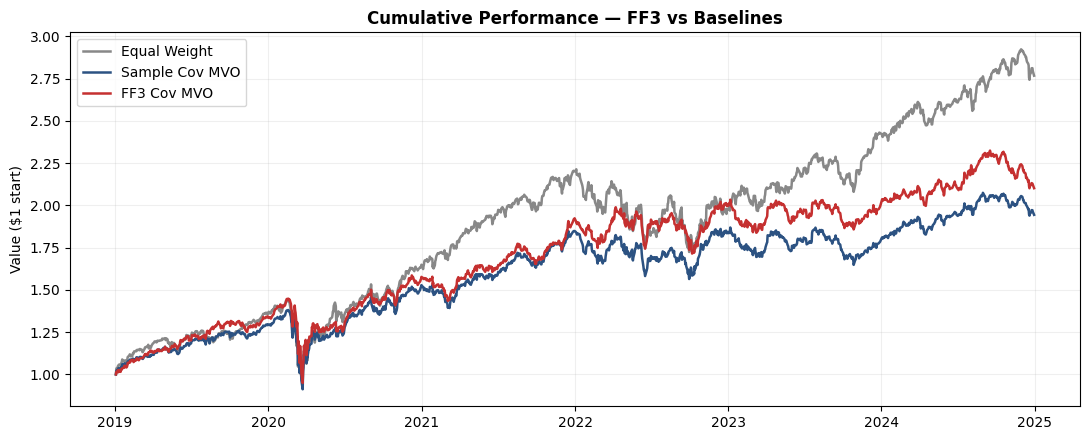

,Ret%,Vol%,Sharpe,MaxDD%
Equal Weight,19.00,19.86,0.96,-34.27
Sample Cov MVO,12.59,17.18,0.73,-33.97
FF3 Cov MVO,13.98,17.66,0.79,-34.46


In [9]:
# ── §4  Results ────────────────────────────────────────────
C = {'Equal Weight':'#888','Sample Cov MVO':'#2c5282','FF3 Cov MVO':'#c53030'}

fig, ax = plt.subplots(figsize=(11, 4.5))
for k in portfolio_df: ax.plot(portfolio_df.index, portfolio_df[k], label=k, color=C[k], lw=1.8)
ax.set_ylabel('Value ($1 start)'); ax.set_title('Cumulative Performance — FF3 vs Baselines', fontweight='bold')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.2); plt.tight_layout(); plt.show()

# Metrics
def metrics(v):
    r = v.pct_change().dropna()
    ar, av = r.mean()*252, r.std()*np.sqrt(252)
    return {'Ret%': ar*100, 'Vol%': av*100, 'Sharpe': ar/av if av>0 else 0,
            'MaxDD%': ((v/v.cummax())-1).min()*100}
display(pd.DataFrame({k: metrics(portfolio_df[k]) for k in portfolio_df}).T.round(2))

---
## 5. Interpretation

Use the chart and summary table to evaluate FF3 on risk-adjusted outcomes, not just headline return.

1. **FF3 vs sample covariance**: Compare realized volatility and Sharpe side by side. If FF3 delivers similar return with lower realized vol, the factor structure is adding useful regularization.

2. **FF3 vs CAPM (M3)**: The relevant question is whether SMB/HML exposures add incremental explanatory power after market beta. Outperformance should show up through more stable risk forecasts and better ex-post efficiency.

3. **Stress behavior**: Review drawdown windows (for example 2020 and 2022). During market stress, correlation regimes shift and idiosyncratic terms can become correlated; this is where static factor models are most fragile.

4. **Implementation fit**: FF3 is generally appropriate for diversified multi-sector equity universes with dispersion in size and value profiles. It is less informative in narrow universes where names share similar factor loadings.

<!-- Add a short analyst conclusion (~150-200 words) linking your observed metrics to portfolio construction implications. -->

---
<p style='text-align:center; color:#8fadc8; font-style:italic; font-size:0.85em;'>
Module 4 complete &mdash; refer to the integration notebook for a cross-model comparison.
</p>